In [7]:
#!pip install pgmpy -quiet

In [8]:
import pandas as pd
import numpy as np
from pgmpy.models import MarkovChain as MC
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
data = pd.read_csv('../data/data_globant_cleaned.csv')

In [10]:
engage = data['Engagement']
engage.head()

0    3.04
1    2.99
2    2.97
3    2.75
4    3.15
Name: Engagement, dtype: float64

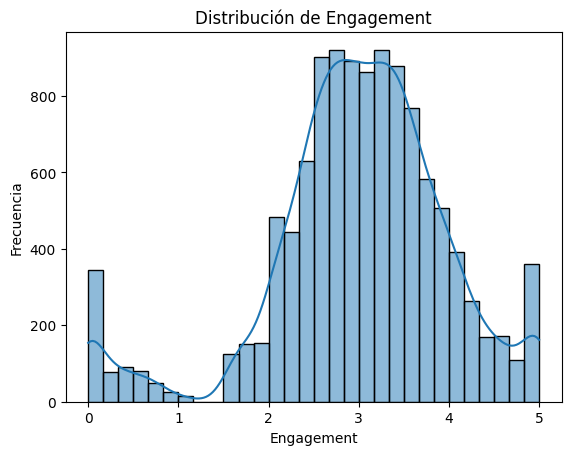

In [11]:
sns.histplot(engage, bins=30, kde=True)
plt.title('Distribución de Engagement')
plt.xlabel('Engagement')
plt.ylabel('Frecuencia')
plt.show()

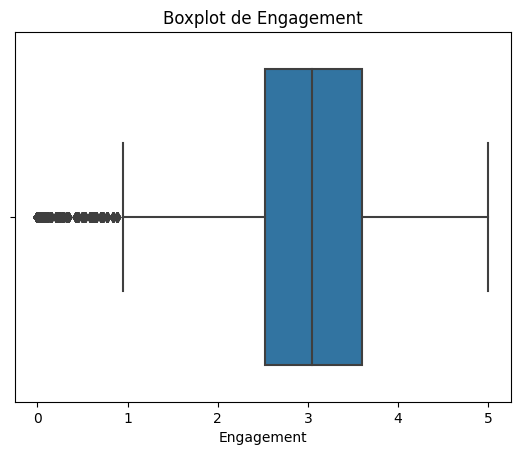

In [12]:
sns.boxplot(x=engage)
plt.title('Boxplot de Engagement')
plt.xlabel('Engagement')
plt.show()

In [13]:
promedio_engage = engage.mean()
print(f'El promedio de Engagement es: {promedio_engage}')
mediana_engage = engage.median()
print(f'La mediana de Engagement es: {mediana_engage}')
moda_engage = engage.mode()[0]
print(f'La moda de Engagement es: {moda_engage}')
standard_dev_engage = engage.std()
print(f'La desviación estándar de Engagement es: {standard_dev_engage}')

El promedio de Engagement es: 2.9952516276614465
La mediana de Engagement es: 3.05
La moda de Engagement es: 0.0
La desviación estándar de Engagement es: 1.0054421221567302


In [14]:
outliers = engage[engage < (promedio_engage - 1.5 * engage.std())]
print(f'Número de outliers en Engagement: {len(outliers)}')
zeros = outliers[outliers == 0]
print(f'Número de ceros en Engagement: {len(zeros)}')

Número de outliers en Engagement: 679
Número de ceros en Engagement: 268


In [15]:
first_threshold = engage.quantile(0.2)
second_threshold = engage.quantile(0.4)
third_threshold = engage.quantile(0.6)
fourth_threshold = engage.quantile(0.8)
print(f'Primer umbral (20%): {first_threshold}')
print(f'Segundo umbral (40%): {second_threshold}')
print(f'Tercer umbral (60%): {third_threshold}')
print(f'Cuarto umbral (80%): {fourth_threshold}')

Primer umbral (20%): 2.41
Segundo umbral (40%): 2.85
Tercer umbral (60%): 3.27
Cuarto umbral (80%): 3.74


In [16]:
engage_states = [1,2,3,4,5]
def categorize_engagement(value):
    if value <= first_threshold:
        return 1
    elif value <= second_threshold and value > first_threshold:
        return 2
    elif value <= third_threshold and value > second_threshold:
        return 3
    elif value <= fourth_threshold and value > third_threshold:
        return 4
    elif value > fourth_threshold:
        return 5
    
engage_categorized = engage.apply(categorize_engagement)
engage_categorized.head()

0    3
1    3
2    3
3    2
4    3
Name: Engagement, dtype: int64

In [17]:
data['Engagement_Cat'] = engage_categorized

In [18]:
data.head()

,Date,Name,Position,Seniority,Location,Studio,Client Tag,Project Tag,Team Name,Engagement,Leader Name,Engagement Group,Engagement_Cat
0,2023-01-02,Natalia Ramírez,Software Developer,Jr,CO/ANT/MED,Engineering,GWI001,ATLINT,Breaking Badger,3.04,Laura Leon,3,3
1,2023-01-03,Natalia Ramírez,Software Developer,Jr,CO/ANT/MED,Engineering,GWI001,ATLINT,Breaking Badger,2.99,Laura Leon,3,3
2,2023-01-04,Natalia Ramírez,Software Developer,Jr,CO/ANT/MED,Engineering,GWI001,ATLINT,Breaking Badger,2.97,Laura Leon,3,3
3,2023-01-05,Natalia Ramírez,Software Developer,Jr,CO/ANT/MED,Engineering,GWI001,ATLINT,Breaking Badger,2.75,Laura Leon,2,2
4,2023-01-06,Natalia Ramírez,Software Developer,Jr,CO/ANT/MED,Engineering,GWI001,ATLINT,Breaking Badger,3.15,Laura Leon,3,3


Prueba de Kolmogorov-Smirnov para normalidad

Estadístico KS: 0.24526733468242967, Valor p: 0.0
Rechazamos la hipótesis nula: Los datos no siguen una distribución normal.


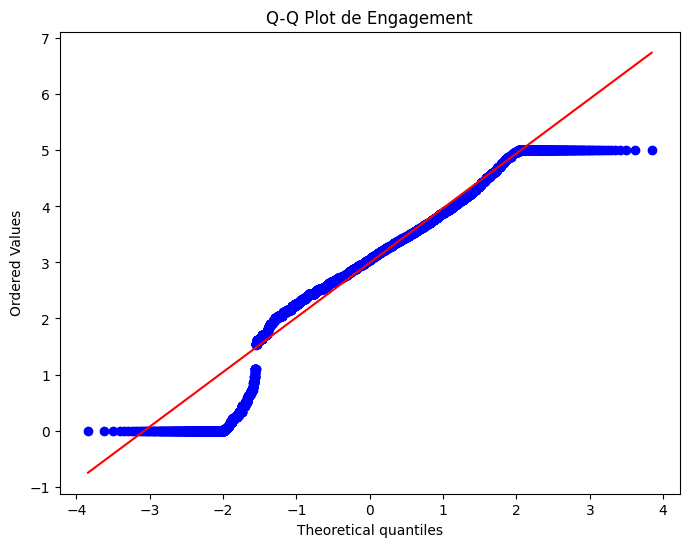

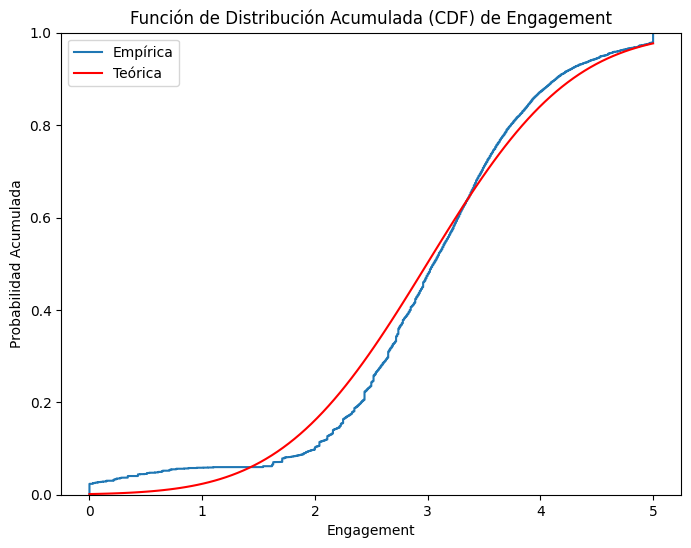

In [19]:
from scipy import stats
ks_statistic, p_value = stats.kstest(engage_categorized, 'norm', args=(promedio_engage, standard_dev_engage))
print(f'Estadístico KS: {ks_statistic}, Valor p: {p_value}')
if p_value < 0.05:
    print('Rechazamos la hipótesis nula: Los datos no siguen una distribución normal.')
else:
    print('No rechazamos la hipótesis nula: Los datos siguen una distribución normal.')
    
plt.figure(figsize=(8, 6))
stats.probplot(engage, dist="norm", plot=plt)
plt.title('Q-Q Plot de Engagement')
plt.show()

plt.figure(figsize=(8, 6))
sns.ecdfplot(engage, label='Empírica')
x = np.linspace(engage.min(), engage.max(), 100)
cdf = stats.norm.cdf(x, loc=promedio_engage, scale=standard_dev_engage)
plt.plot(x, cdf, label='Teórica', color='red')
plt.title('Función de Distribución Acumulada (CDF) de Engagement')
plt.xlabel('Engagement')
plt.ylabel('Probabilidad Acumulada')
plt.legend()
plt.show()

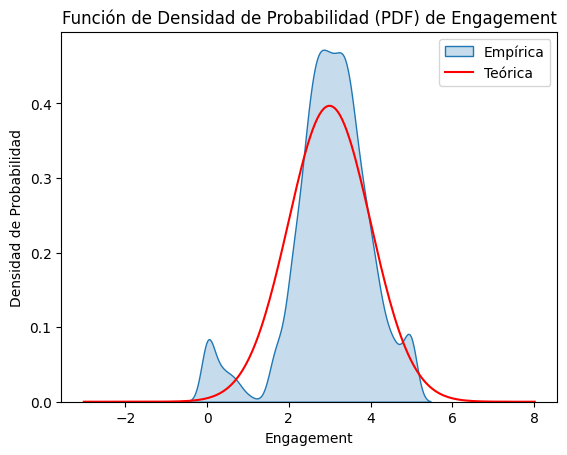

In [20]:
sns.kdeplot(engage, label='Empírica', fill=True)
x = np.linspace(engage.min() - 3*standard_dev_engage,
                engage.max() + 3*standard_dev_engage,
                200)
pdf = stats.norm.pdf(x, loc=promedio_engage, scale=standard_dev_engage)
plt.plot(x, pdf, label='Teórica', color='red')
plt.title('Función de Densidad de Probabilidad (PDF) de Engagement')
plt.xlabel('Engagement')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.show()

In [21]:
stats.skew(engage)
print(f'Asimetría de Engagement: {stats.skew(engage)}')
kurtosis = stats.kurtosis(engage)
print(f'Curtosis de Engagement: {kurtosis}')

Asimetría de Engagement: -0.8180636418030791
Curtosis de Engagement: 1.4845910059052265


Insight para el Reporte:

Aunque teóricamente muchos fenómenos se asumen normales, el análisis gráfico y las pruebas estadísticas demuestran que Engagement presenta asimetría negativa y una distribución platicúrtica, por lo que no sigue una distribución normal. Esto sugiere la presencia de subgrupos o sesgos en los niveles de interacción.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Supongamos que tus datos están en "engage" y son enteros
mu = np.mean(engage)

# Ordenar los datos
sorted_data = np.sort(engage)
n = len(sorted_data)

# Probabilidades empíricas asociadas a cada dato ordenado
p = (np.arange(1, n + 1) - 0.5) / n  # fórmula clásica de cuantiles empíricos

# Cuantiles teóricos de la distribución Poisson (discretos)
q_theo = stats.poisson.ppf(p, mu)

# Revisamos los primeros para ver cómo luce
print("Primeros 10 cuantiles empíricos:", sorted_data[:10])
print("Primeros 10 cuantiles teóricos:", q_theo[:10])


Primeros 10 cuantiles empíricos: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Primeros 10 cuantiles teóricos: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


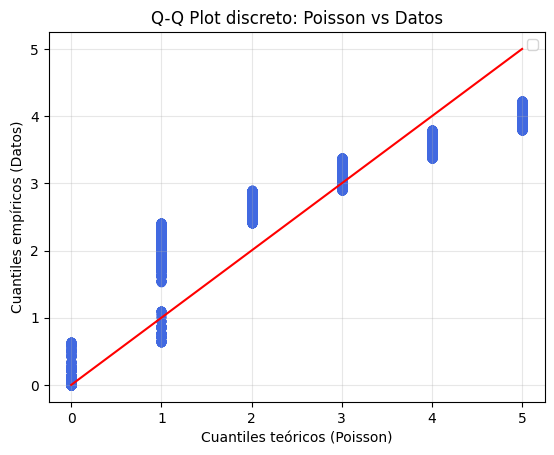

In [23]:
mask = q_theo <= engage.max()
plt.scatter(q_theo[mask], sorted_data[mask], color='royalblue')
plt.plot([0, engage.max()], [0, engage.max()], 'r')
plt.title('Q-Q Plot discreto: Poisson vs Datos')
plt.xlabel('Cuantiles teóricos (Poisson)')
plt.ylabel('Cuantiles empíricos (Datos)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

El Q–Q plot discreto muestra que los cuantiles empíricos se desvían sistemáticamente de los teóricos en la parte superior de la distribución. Esto indica que el modelo Poisson subestima la frecuencia de valores altos de Engagement, sugiriendo sobredispersión. Por tanto, una distribución Binomial Negativa podría ajustarse mejor a los datos.

N=11366, n_trials=5, media=2.5206, var=1.0221, p̂=0.5041


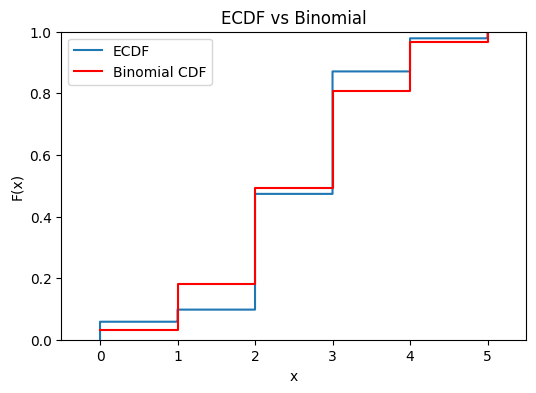

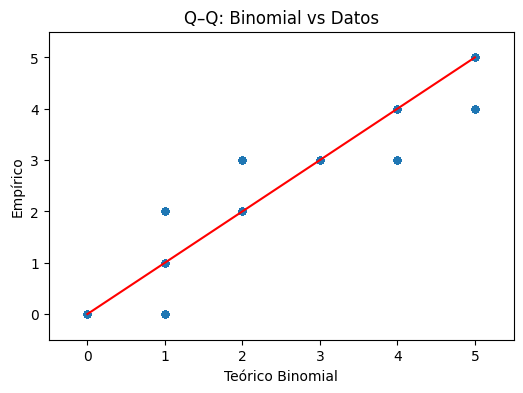

rhô=-0.045557
Sin sobre-dispersión → Beta-Binomial colapsa a Binomial; quédate con Binomial(n=5, p̂).


In [24]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import binom, betabinom

# Datos enteros 0..5
x = np.asarray(engage).astype(int)
n_trials = 5                 # ensayos por observación (F I J O)
N = len(x)                   # tamaño de muestra

# p y estadísticos
m = x.mean()
s2 = x.var(ddof=1)
p_hat = m / n_trials
print(f"N={N}, n_trials={n_trials}, media={m:.4f}, var={s2:.4f}, p̂={p_hat:.4f}")

# ECDF vs Binomial
plt.figure(figsize=(6,4))
sns.ecdfplot(x, label='ECDF')
k = np.arange(0, n_trials+1)
plt.step(k, binom.cdf(k, n_trials, p_hat), where='post', color='r', label='Binomial CDF')
plt.xlim(-0.5, n_trials+0.5)
plt.xlabel('x'); plt.ylabel('F(x)'); plt.legend(); plt.title('ECDF vs Binomial'); plt.show()

# Q–Q Binomial (discreto)
x_sorted = np.sort(x)
p_emp = (np.arange(1, N+1) - 0.5)/N
q_bin = binom.ppf(p_emp, n_trials, p_hat)
plt.figure(figsize=(6,4))
plt.scatter(q_bin, x_sorted, s=18)
plt.plot([0, n_trials], [0, n_trials], 'r')
plt.xlim(-0.5, n_trials+0.5); plt.ylim(-0.5, n_trials+0.5)
plt.xlabel('Teórico Binomial'); plt.ylabel('Empírico'); plt.title('Q–Q: Binomial vs Datos'); plt.show()

# Overdispersion rhô y Beta-Binomial (solo si rhô>0)
rho_hat = (s2 - n_trials*p_hat*(1-p_hat)) / (n_trials*p_hat*(1-p_hat)*(n_trials-1))
print(f"rhô={rho_hat:.6f}")
if rho_hat > 0:
    alpha = p_hat*(1-rho_hat)/rho_hat
    beta  = (1-p_hat)*(1-rho_hat)/rho_hat
    print(f"Beta-Binomial params: α={alpha:.3f}, β={beta:.3f}")

    # ECDF vs Beta-Binomial
    plt.figure(figsize=(6,4))
    sns.ecdfplot(x, label='ECDF')
    plt.step(k, betabinom.cdf(k, n_trials, alpha, beta), where='post', color='r', label='Beta-Binomial CDF')
    plt.xlim(-0.5, n_trials+0.5); plt.xlabel('x'); plt.ylabel('F(x)'); plt.legend(); plt.title('ECDF vs Beta-Binomial'); plt.show()

    # Q–Q Beta-Binomial
    q_bb = betabinom.ppf(p_emp, n_trials, alpha, beta)
    plt.figure(figsize=(6,4))
    plt.scatter(q_bb, x_sorted, s=18)
    plt.plot([0, n_trials], [0, n_trials], 'r')
    plt.xlim(-0.5, n_trials+0.5); plt.ylim(-0.5, n_trials+0.5)
    plt.xlabel('Teórico Beta-Binomial'); plt.ylabel('Empírico'); plt.title('Q–Q: Beta-Binomial vs Datos'); plt.show()
else:
    print("Sin sobre-dispersión → Beta-Binomial colapsa a Binomial; quédate con Binomial(n=5, p̂).")

In [25]:
import numpy as np

x = np.asarray(engage).astype(int)   # serie temporal
max_state = x.max()
min_state = x.min()
states = np.arange(min_state, max_state+1)
k = len(states)

# mapeo por si min_state != 0
idx = {s:i for i,s in enumerate(states)}

P = np.zeros((k,k))

for i in range(len(x)-1):
    a = idx[x[i]]
    b = idx[x[i+1]]
    P[a,b] += 1

row_sums = P.sum(axis=1, keepdims=True)
P_norm = np.divide(P, row_sums, out=np.zeros_like(P), where=row_sums!=0)

print("Matriz de transición:")
print(P_norm)
print("Suma por fila:", P_norm.sum(axis=1))

Matriz de transición:
[[4.32228916e-01 3.16265060e-02 3.16265060e-01 1.82228916e-01
  3.61445783e-02 1.50602410e-03]
 [4.92170022e-02 6.46532438e-01 2.52796421e-01 3.35570470e-02
  1.11856823e-02 6.71140940e-03]
 [4.70725995e-02 2.85714286e-02 7.24355972e-01 1.96955504e-01
  2.81030445e-03 2.34192037e-04]
 [2.81035627e-02 2.21287896e-03 1.88315999e-01 6.99933614e-01
  8.01062182e-02 1.32772737e-03]
 [2.04582651e-02 3.27332242e-03 3.27332242e-03 3.06055646e-01
  6.30932897e-01 3.60065466e-02]
 [8.23045267e-03 4.11522634e-03 0.00000000e+00 1.64609053e-02
  1.97530864e-01 7.73662551e-01]]
Suma por fila: [1. 1. 1. 1. 1. 1.]


In [26]:
from pgmpy.models import MarkovChain


model = MarkovChain(["eng"], [6])   # 0..5 -> card=6
model.add_transition_model("eng", P_norm)

In [27]:
import numpy as np

k = len(states)
pi0 = np.zeros(k)
pi0[idx[3]] = 1.0   # estado inicial = 3

n = 1  # pasos adelante
P_n = np.linalg.matrix_power(P_norm, n)
pi_n = pi0 @ P_n    # distribución después de n pasos

print("Distribución después de", n, "pasos:")
for s, p in zip(states, pi_n):
    print(f"  P(X_{n} = {s}) = {p:.4f}")

Distribución después de 1 pasos:
  P(X_1 = 0) = 0.0281
  P(X_1 = 1) = 0.0022
  P(X_1 = 2) = 0.1883
  P(X_1 = 3) = 0.6999
  P(X_1 = 4) = 0.0801
  P(X_1 = 5) = 0.0013


In [28]:
data.head()

,Date,Name,Position,Seniority,Location,Studio,Client Tag,Project Tag,Team Name,Engagement,Leader Name,Engagement Group,Engagement_Cat
0,2023-01-02,Natalia Ramírez,Software Developer,Jr,CO/ANT/MED,Engineering,GWI001,ATLINT,Breaking Badger,3.04,Laura Leon,3,3
1,2023-01-03,Natalia Ramírez,Software Developer,Jr,CO/ANT/MED,Engineering,GWI001,ATLINT,Breaking Badger,2.99,Laura Leon,3,3
2,2023-01-04,Natalia Ramírez,Software Developer,Jr,CO/ANT/MED,Engineering,GWI001,ATLINT,Breaking Badger,2.97,Laura Leon,3,3
3,2023-01-05,Natalia Ramírez,Software Developer,Jr,CO/ANT/MED,Engineering,GWI001,ATLINT,Breaking Badger,2.75,Laura Leon,2,2
4,2023-01-06,Natalia Ramírez,Software Developer,Jr,CO/ANT/MED,Engineering,GWI001,ATLINT,Breaking Badger,3.15,Laura Leon,3,3


In [29]:
def transition_matrix_for_subset(df, mask, col_eng='Engagement_Cat', n_states=6):
    sub = df[mask].sort_values(['Name','Date'])
    x = sub[col_eng].to_numpy().astype(int)
    P_counts = np.zeros((n_states, n_states))
    for i in range(len(x)-1):
        a, b = x[i], x[i+1]
        P_counts[a,b] += 1
    row_sums = P_counts.sum(axis=1, keepdims=True)
    P = np.divide(P_counts, row_sums, out=np.zeros_like(P_counts), where=row_sums!=0)
    return P

def prob_mejorar(P):
    total = 0
    for i in range(P.shape[0]):
        total += np.sum(P[i, i+1:])
    return total / P.shape[0]

def prob_empeorar(P):
    total = 0
    for i in range(P.shape[0]):
        total += np.sum(P[i, :i])
    return total / P.shape[0]

def estacionaria(P):
    vals, vecs = np.linalg.eig(P.T)
    idx = np.argmin(np.abs(vals - 1))
    pi = np.real(vecs[:, idx])
    pi = pi / pi.sum()
    return pi

In [30]:
P_proyA = transition_matrix_for_subset(data, data['Project Tag']=='CATPRO')
P_proyB = transition_matrix_for_subset(data, data['Project Tag']=='NEXDEV')

In [31]:
print("CATPRO:\n", np.round(P_proyA,3))
print("NEXDEV:\n", np.round(P_proyB,3))

CATPRO:
 [[0.    0.    0.    0.    0.    0.   ]
 [0.    0.712 0.16  0.053 0.051 0.024]
 [0.    0.225 0.477 0.172 0.121 0.005]
 [0.    0.075 0.174 0.349 0.344 0.058]
 [0.    0.038 0.064 0.255 0.43  0.213]
 [0.    0.029 0.002 0.055 0.211 0.704]]
NEXDEV:
 [[0.    0.    0.    0.    0.    0.   ]
 [0.    0.636 0.164 0.06  0.063 0.078]
 [0.    0.111 0.567 0.183 0.127 0.012]
 [0.    0.061 0.21  0.348 0.322 0.058]
 [0.    0.037 0.098 0.213 0.412 0.24 ]
 [0.    0.034 0.013 0.059 0.295 0.598]]


In [32]:
print("Probabilidad de mejorar en CATPRO:", prob_mejorar(P_proyA))
print("Probabilidad de mejorar en NEXDEV:", prob_mejorar(P_proyB))

print("Probabilidad de empeorar en CATPRO:", prob_empeorar(P_proyA))
print("Probabilidad de empeorar en NEXDEV:", prob_empeorar(P_proyB))

Probabilidad de mejorar en CATPRO: 0.20009054857038677
Probabilidad de mejorar en NEXDEV: 0.21785053399152654
Probabilidad de empeorar en CATPRO: 0.1878736089696841
Probabilidad de empeorar en NEXDEV: 0.18863288587025195


In [33]:
pi_A = estacionaria(P_proyA)
pi_B = estacionaria(P_proyB)

print("Estacionaria CATPRO:", np.round(pi_A,3))
print("Estacionaria NEXDEV:", np.round(pi_B,3))

Estacionaria CATPRO: [-0.     0.217  0.152  0.169  0.237  0.224]
Estacionaria NEXDEV: [-0.     0.139  0.204  0.176  0.264  0.216]


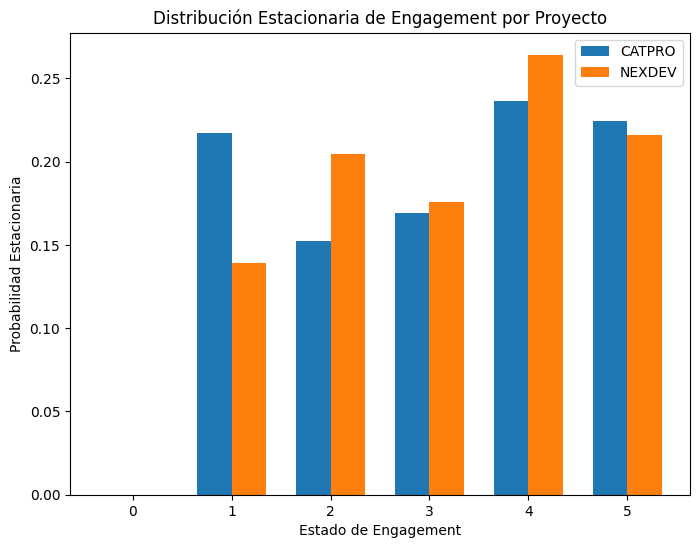

In [34]:
plt.figure(figsize=(8, 6))
states = np.arange(P_proyA.shape[0])
width = 0.35
plt.bar(states - width/2, pi_A, width=width, label='CATPRO')
plt.bar(states + width/2, pi_B, width=width, label='NEXDEV')
plt.xlabel('Estado de Engagement')
plt.ylabel('Probabilidad Estacionaria')
plt.title('Distribución Estacionaria de Engagement por Proyecto')
plt.xticks(states)
plt.legend()
plt.show()

In [35]:
P_proyS = transition_matrix_for_subset(data, data['Seniority']=='Ssr')
P_proyJ = transition_matrix_for_subset(data, data['Seniority']=='Jr')

print("Seniors:\n", np.round(P_proyS,3))
print("Juniors:\n", np.round(P_proyJ,3))

Seniors:
 [[0.    0.    0.    0.    0.    0.   ]
 [0.    0.762 0.153 0.045 0.028 0.012]
 [0.    0.258 0.463 0.183 0.089 0.007]
 [0.    0.089 0.252 0.38  0.252 0.027]
 [0.    0.038 0.128 0.289 0.426 0.119]
 [0.    0.028 0.    0.057 0.136 0.78 ]]
Juniors:
 [[0.    0.    0.    0.    0.    0.   ]
 [0.    0.345 0.071 0.31  0.06  0.214]
 [0.    0.025 0.771 0.137 0.063 0.004]
 [0.    0.082 0.117 0.601 0.177 0.022]
 [0.    0.032 0.079 0.201 0.444 0.244]
 [0.    0.038 0.    0.013 0.204 0.745]]


Probabilidad de mejorar como Senior: 0.15270267980578972
Probabilidad de mejorar como Junior: 0.217013657341414
Probabilidad de empeorar como Senior: 0.2122288672066416
Probabilidad de empeorar como Junior: 0.13186987950113457
Estacionaria Senior: [-0.     0.332  0.211  0.171  0.155  0.131]
Estacionaria Junior: [-0.     0.064  0.213  0.238  0.209  0.276]


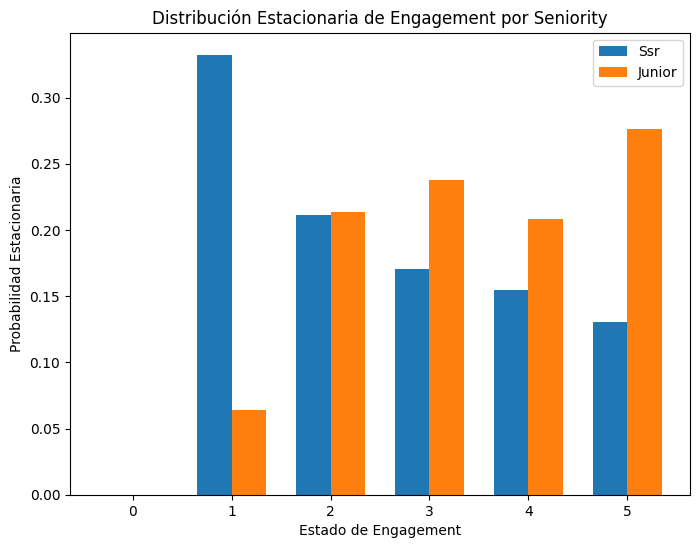

In [36]:
pi_S = estacionaria(P_proyS)
pi_J = estacionaria(P_proyJ)

print("Probabilidad de mejorar como Senior:", prob_mejorar(P_proyS))
print("Probabilidad de mejorar como Junior:", prob_mejorar(P_proyJ))

print("Probabilidad de empeorar como Senior:", prob_empeorar(P_proyS))
print("Probabilidad de empeorar como Junior:", prob_empeorar(P_proyJ))

print("Estacionaria Senior:", np.round(pi_S,3))
print("Estacionaria Junior:", np.round(pi_J,3))

plt.figure(figsize=(8, 6))
states = np.arange(P_proyS.shape[0])
width = 0.35
plt.bar(states - width/2, pi_S, width=width, label='Ssr')
plt.bar(states + width/2, pi_J, width=width, label='Junior')
plt.xlabel('Estado de Engagement')
plt.ylabel('Probabilidad Estacionaria')
plt.title('Distribución Estacionaria de Engagement por Seniority')
plt.xticks(states)
plt.legend()
plt.show()

Software Developer:
 [[0.    0.    0.    0.    0.    0.   ]
 [0.    0.73  0.147 0.065 0.034 0.024]
 [0.    0.171 0.464 0.228 0.131 0.006]
 [0.    0.067 0.239 0.426 0.234 0.033]
 [0.    0.054 0.149 0.282 0.367 0.149]
 [0.    0.032 0.005 0.039 0.232 0.693]]
Business Analyst:
 [[0.    0.    0.    0.    0.    0.   ]
 [0.    0.83  0.085 0.006 0.036 0.042]
 [0.    0.349 0.279 0.07  0.279 0.023]
 [0.    0.025 0.099 0.358 0.407 0.111]
 [0.    0.015 0.046 0.165 0.459 0.314]
 [0.    0.025 0.    0.05  0.169 0.755]]
Quality Assurance Tester:
 [[0.    0.    0.    0.    0.    0.   ]
 [0.    0.754 0.128 0.047 0.039 0.033]
 [0.    0.229 0.405 0.19  0.137 0.039]
 [0.    0.106 0.242 0.261 0.267 0.124]
 [0.    0.039 0.163 0.192 0.414 0.192]
 [0.    0.082 0.048 0.163 0.238 0.469]]
Probabilidad de mejorar como Software Developer: 0.1750856925801475
Probabilidad de mejorar como Business Analyst: 0.229123583527004
Probabilidad de mejorar como Quality Assurance Tester: 0.19926117235843352
Probabilidad de empe

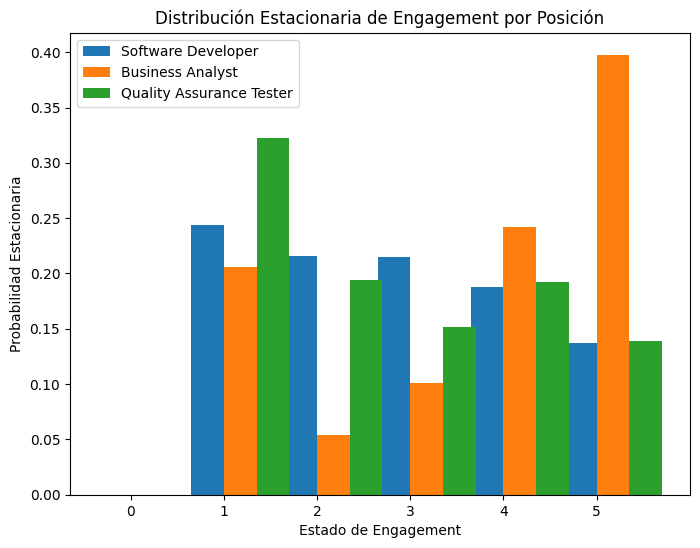

In [37]:
P_proySD = transition_matrix_for_subset(data, data['Position']=='Software Developer')
P_proyBE = transition_matrix_for_subset(data, data['Position']=='Business Analyst')
#P_proySE = transition_matrix_for_subset(data, data['Position']=='Software Engineer')
P_proyQA = transition_matrix_for_subset(data, data['Position']=='Quality Assurance Tester')


print("Software Developer:\n", np.round(P_proySD,3))
print("Business Analyst:\n", np.round(P_proyBE,3))
#print("Software Engineer:\n", np.round(P_proySE,3))
print("Quality Assurance Tester:\n", np.round(P_proyQA,3))

pi_SD = estacionaria(P_proySD)
pi_BE = estacionaria(P_proyBE)
#pi_SE = estacionaria(P_proySE)
pi_QA = estacionaria(P_proyQA)

print("Probabilidad de mejorar como Software Developer:", prob_mejorar(P_proySD))
print("Probabilidad de mejorar como Business Analyst:", prob_mejorar(P_proyBE))
#print("Probabilidad de mejorar como Software Engineer:", prob_mejorar(P_proySE))
print("Probabilidad de mejorar como Quality Assurance Tester:", prob_mejorar(P_proyQA))

print("Probabilidad de empeorar como Software Developer:", prob_empeorar(P_proySD))
print("Probabilidad de empeorar como Business Analyst:", prob_empeorar(P_proyBE))
#print("Probabilidad de empeorar como Software Engineer:", prob_empeorar(P_proySE))
print("Probabilidad de empeorar como Quality Assurance Tester:", prob_empeorar(P_proyQA))

print("Estacionaria Software Developer:", np.round(pi_SD,3))
print("Estacionaria Business Analyst:", np.round(pi_BE,3))
#print("Estacionaria Software Engineer:", np.round(pi_SE,3))
print("Estacionaria Quality Assurance Tester:", np.round(pi_QA,3))

plt.figure(figsize=(8, 6))
states = np.arange(P_proySD.shape[0])
width = 0.35
plt.bar(states - width/2, pi_SD, width=width, label='Software Developer')
plt.bar(states + width/2, pi_BE, width=width, label='Business Analyst')
#plt.bar(states + 3*width/2, pi_SE, width=width, label='Software Engineer')
plt.bar(states + 3*width/2, pi_QA, width=width, label='Quality Assurance Tester')
plt.xlabel('Estado de Engagement')
plt.ylabel('Probabilidad Estacionaria')
plt.title('Distribución Estacionaria de Engagement por Posición')
plt.xticks(states)
plt.legend()
plt.show()

Position, Location y Project Tag

In [38]:
def engage_forecast_filtered(df, filter_col, filter_value, col_eng='Engagement_Cat', n_states=6, n_steps=1, initial_state=3):
    mask = df[filter_col] == filter_value
    P = transition_matrix_for_subset(df, mask, col_eng, n_states)
    k = n_states
    pi0 = np.zeros(k)
    pi0[initial_state] = 1.0
    P_n = np.linalg.matrix_power(P, n_steps)
    pi_n = pi0 @ P_n
    return pi_n

engage_forecast_filtered(data, 'Project Tag', 'CATPRO', n_steps=3)
engage_forecast_filtered(data, 'Project Tag', 'NEXDEV', n_steps=3)
engage_forecast_filtered(data, 'Seniority', 'Ssr', n_steps=3)
engage_forecast_filtered(data, 'Seniority', 'Jr', n_steps=3)
engage_forecast_filtered(data, 'Position', 'Software Developer', n_steps=3)
engage_forecast_filtered(data, 'Position', 'Business Analyst', n_steps=3)
#engage_forecast_filtered(data, 'Position', 'Software Engineer', n_steps=3)
engage_forecast_filtered(data, 'Position', 'Quality Assurance Tester', n_steps=3)

array([0.        , 0.23207094, 0.20783774, 0.17382467, 0.22768421,
       0.15858244])

In [39]:
def transition_matrix_for_subsubset(df, mask1, mask2, col_eng='Engagement_Cat', n_states=6):
transition_matrix_for_subset(data, data['Position']=='Software Developer')

IndentationError: expected an indented block after function definition on line 1 (2728033864.py, line 2)